In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def show_image(image, title="Image", cmap_type=None):
    plt.figure(figsize=(6, 4))
    plt.imshow(image, cmap=cmap_type)
    plt.title(title)
    plt.axis('off')
    plt.show()

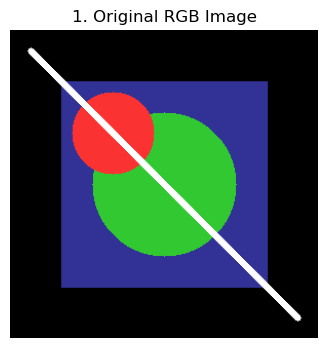

In [6]:
# 1.  การโหลดและแสดงผลภาพสี
img_bgr = np.zeros((300, 300, 3), dtype=np.uint8)
cv2.rectangle(img_bgr, (50, 50), (250, 250), (150, 50, 50), -1) # สี่เหลี่ยม
cv2.circle(img_bgr, (150, 150), 70, (50, 200, 50), -1) # วงกลมตรงกลาง
cv2.circle(img_bgr, (100, 100), 40, (50, 50, 250), -1) # วงกลมซ้อนทับมุมซ้าย
cv2.line(img_bgr, (20, 20), (280, 280), (255, 255, 255), 5) # เส้นทแยงมุมสีขาว

# แปลง BGR เป็น RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

show_image(img_rgb, "1. Original RGB Image")

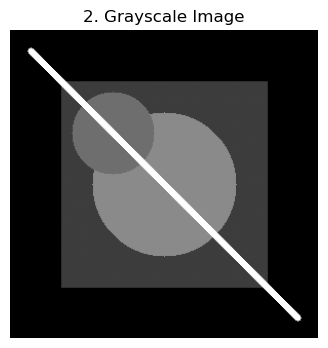

In [7]:
# 2: การแปลงภาพสีเป็นภาพขาวดำ (Grayscale)
# แปลงภาพจาก RGB/BGR เป็นภาพขาวดำ
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# แสดงผลโดยระบุ cmap='gray'
show_image(img_gray, "2. Grayscale Image", cmap_type='gray')

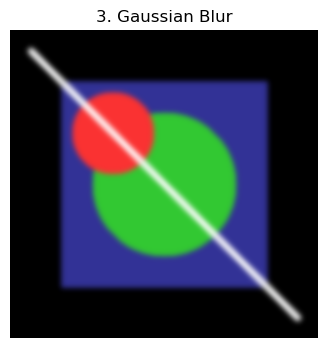

In [8]:
# 3: การเบลอภาพ (Gaussian Blur)
# ใช้ Gaussian Blur โดยกำหนดขนาด Kernel เป็น (15, 15)
# ตัวเลขใน Kernel ยิ่งมาก ภาพยิ่งเบลอ
img_blur = cv2.GaussianBlur(img_rgb, (15, 15), 0)

show_image(img_blur, "3. Gaussian Blur")

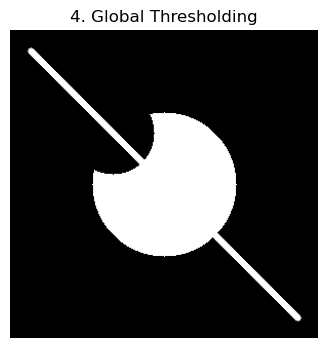

In [9]:
# 4: Global Thresholding (การแบ่งส่วนด้วยค่าคงที่)
# พิกเซลที่ความสว่าง > 127 จะกลายเป็น 255 (ขาว) ที่เหลือเป็น 0 (ดำ)
ret, thresh_global = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

show_image(thresh_global, "4. Global Thresholding", cmap_type='gray')

ค่า Threshold ที่คำนวณได้จาก Otsu: 61.0


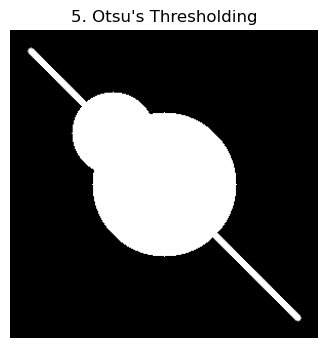

In [10]:
# 5: Otsu's Thresholding หาค่า Threshold ที่เหมาะสมที่สุดให้โดยอัตโนมัติ
# เพิ่มแฟล็ก cv2.THRESH_OTSU เข้าไป ค่า 0 ที่ใส่ไปตอนแรกจะถูกข้ามไปคำนวณใหม่
ret_otsu, thresh_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"ค่า Threshold ที่คำนวณได้จาก Otsu: {ret_otsu}")
show_image(thresh_otsu, "5. Otsu's Thresholding", cmap_type='gray')

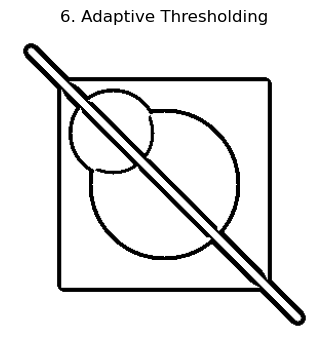

In [11]:
# 6: Adaptive Thresholding เหมาะสำหรับภาพที่มีแสงสว่างไม่เท่ากัน อัลกอริทึมจะคำนวณ Threshold แบบแยกส่วน
# คำนวณขีดจำกัดจากพื้นที่ย่อยขนาด 11x11 พิกเซล
thresh_adapt = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                     cv2.THRESH_BINARY, 11, 2)

show_image(thresh_adapt, "6. Adaptive Thresholding", cmap_type='gray')

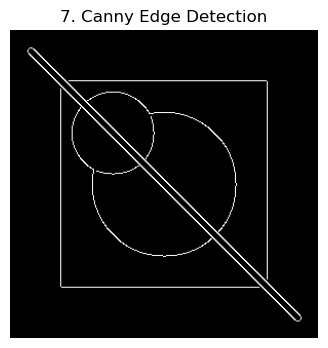

In [12]:
# 7: Canny Edge Detection (ตรวจจับเส้นขอบ) หาขอบของวัตถุในภาพ มักใช้ต่อจากการทำ Grayscale หรือ Blur
# กำหนดค่า Min Threshold = 100 และ Max Threshold = 200
edges = cv2.Canny(img_gray, 100, 200)

show_image(edges, "7. Canny Edge Detection", cmap_type='gray')

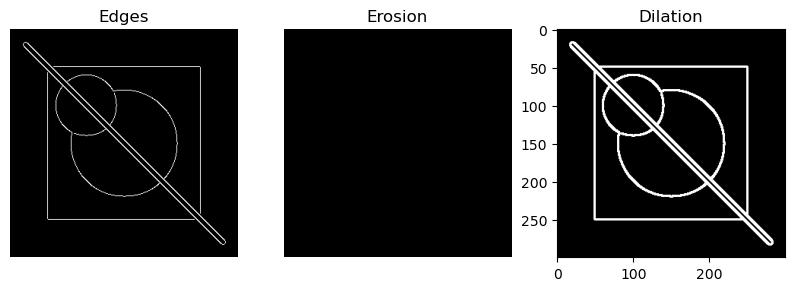

In [13]:
# 8: Image Morphology (Erosion & Dilation) การกัดกร่อน (Erosion) และการขยาย (Dilation) พิกเซลสีขาว

kernel = np.ones((3,3), np.uint8)

# กัดกร่อนภาพ (ทำให้เส้นเล็กลง / ลบ noise)
image = edges
erosion = cv2.erode(image, kernel, iterations=1) # img_gray, edges

# ขยายภาพ (ทำให้เส้นหนาขึ้น / เชื่อมรอยต่อ)
dilation = cv2.dilate(image, kernel, iterations=1)

# แสดงผลเปรียบเทียบ
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4))
ax1.imshow(image, cmap='gray'); ax1.set_title('Edges'); ax1.axis('off')
ax2.imshow(erosion, cmap='gray'); ax2.set_title('Erosion'); ax1.axis('off')
ax3.imshow(dilation, cmap='gray'); ax3.set_title('Dilation'); ax2.axis('off')
plt.show()

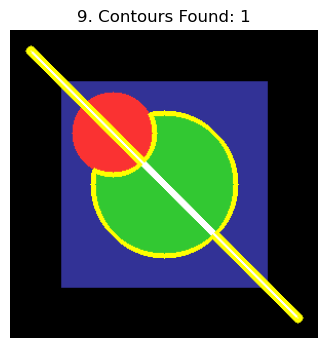

In [14]:
# 9: การหาและวาดเส้นรอบรูป (Contours) ดึงข้อมูลรูปทรงออกมาจากภาพ Binary แล้วนำมาวาดทับภาพต้นฉบับ
# หาเส้นรอบรูปจากภาพที่ผ่าน Thresholding
contours, hierarchy = cv2.findContours(thresh_global, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# คัดลอกภาพต้นฉบับเพื่อนำมาวาดเส้น
img_contours = img_rgb.copy()

cv2.drawContours(img_contours, contours, -1, (255, 255, 0), 3)

show_image(img_contours, f"9. Contours Found: {len(contours)}")

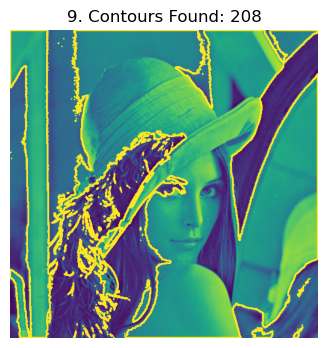

In [ ]:
import os

# example paths
img_path = os.path.join(os.getcwd(), "images", "lenna.png")

# load an image
image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_xray_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
img_xray_gray = cv2.cvtColor(img_xray_rgb, cv2.COLOR_BGR2GRAY)
ret_otsu, thresh_otsu = cv2.threshold(img_xray_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

contours, hierarchy = cv2.findContours(thresh_otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# คัดลอกภาพต้นฉบับเพื่อนำมาวาดเส้น
img_contours = img_xray_gray.copy()

# วาดเส้นรอบรูปสีเขียว (0, 255, 0) ความหนา 3 พิกเซล
cv2.drawContours(img_contours, contours, -1, (255, 0, 255), 2)

show_image(img_contours, f"9. Contours Found: {len(contours)}")

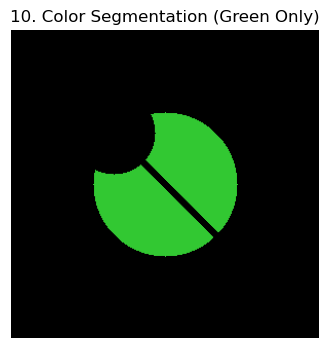

In [23]:
# 10: Color Segmentation ด้วย HSV
# แปลงภาพจาก BGR เป็น HSV
hsv_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# กำหนดช่วงสีที่ต้องการ (ทดสอบหาช่วงสีเขียวจากภาพจำลอง)
lower_color = np.array([40, 50, 50])
upper_color = np.array([80, 255, 255])

# สร้างหน้ากาก (Mask) แยกเฉพาะสี
mask = cv2.inRange(hsv_img, lower_color, upper_color)

# ตัดภาพโดยใช้ Mask (Bitwise AND)
result_color = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

show_image(result_color, "10. Color Segmentation (Green Only)")

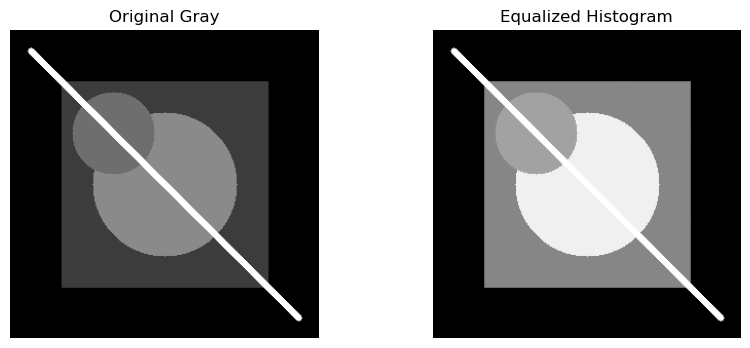

In [24]:
# 11: Histogram Equalization (ปรับสมดุลแสง) ปรับปรุงความเปรียบต่าง (Contrast) ของภาพโดยกระจายค่าความสว่างให้ทั่วถึง

# ปรับสมดุลแสงบนภาพ Grayscale
img_eq = cv2.equalizeHist(img_gray)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(img_gray, cmap='gray'); ax1.set_title('Original Gray'); ax1.axis('off')
ax2.imshow(img_eq, cmap='gray'); ax2.set_title('Equalized Histogram'); ax2.axis('off')
plt.show()

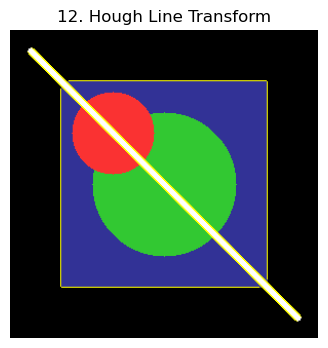

In [ ]:
# 12: Hough Line Transform (ตรวจจับเส้นตรง) ค้นหาเส้นตรงที่ซ่อนอยู่ในภาพจากเส้นขอบ (Edges)
# ตรวจจับเส้นตรงจากภาพ Canny Edges
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=40, minLineLength=30, maxLineGap=10)

img_lines = img_rgb.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_lines, (x1, y1), (x2, y2), (255, 255, 0), 1) # วาดเส้นสีเหลือง

show_image(img_lines, "12. Hough Line Transform")

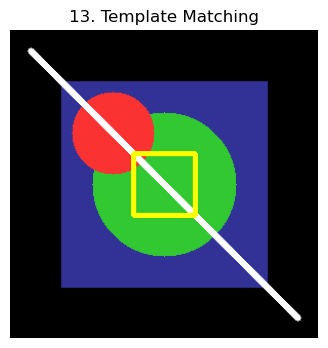

In [29]:
# 13: Template Matching (ค้นหาวัตถุต้นแบบในภาพ) หาตำแหน่งของภาพชิ้นส่วนเล็กๆ (Template) ในภาพใหญ่
# สร้าง Template จำลอง (เอาส่วนหนึ่งของภาพต้นฉบับมา)
template = img_gray[120:180, 120:180] 
w, h = template.shape[::-1]

# ค้นหา Template
res = cv2.matchTemplate(img_gray, template, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)

img_template = img_rgb.copy()
cv2.rectangle(img_template, top_left, bottom_right, (255, 255, 0), 3) # ตีกรอบสีเหลือง

show_image(img_template, "13. Template Matching")

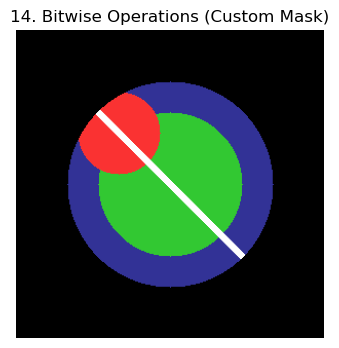

In [30]:
#  14: Bitwise Operations (การตัดภาพด้วย Mask ที่กำหนดเอง) สร้างรูปร่างและนำมาเป็นหน้ากากเจาะภาพ
# สร้าง Mask วงกลมสีขาวบนพื้นดำ
circle_mask = np.zeros(img_gray.shape, dtype="uint8")
cv2.circle(circle_mask, (150, 150), 100, 255, -1)

# ใช้ Bitwise AND เจาะภาพ
masked_img = cv2.bitwise_and(img_rgb, img_rgb, mask=circle_mask)

show_image(masked_img, "14. Bitwise Operations (Custom Mask)")

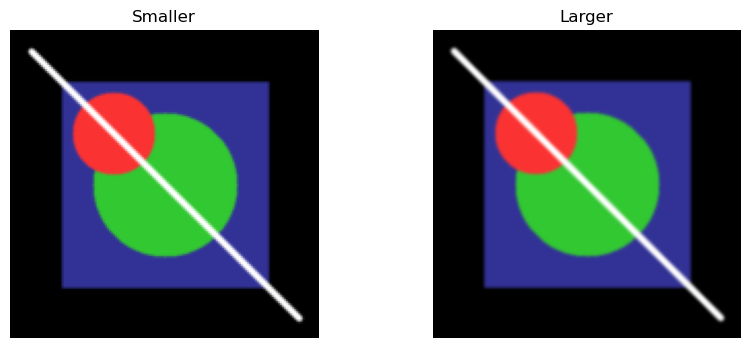

In [34]:
# 15: Image Pyramids (การย่อ/ขยายภาพหลายระดับ) ลดขนาดหรือเพิ่มขนาดภาพอย่างรวดเร็ว (เป็นประโยชน์ในการทำ Feature Blending)

# ย่อภาพลงครึ่งหนึ่ง
smaller = cv2.pyrDown(img_rgb)
# ขยายภาพกลับ (ภาพจะเบลอขึ้นเล็กน้อย)
larger = cv2.pyrUp(smaller)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(smaller); ax1.set_title('Smaller'); ax1.axis('off')
ax2.imshow(larger); ax2.set_title('Larger'); ax2.axis('off')
plt.show()

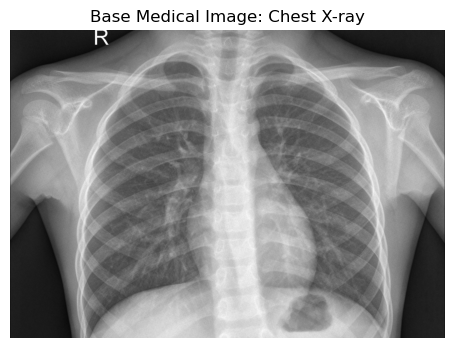

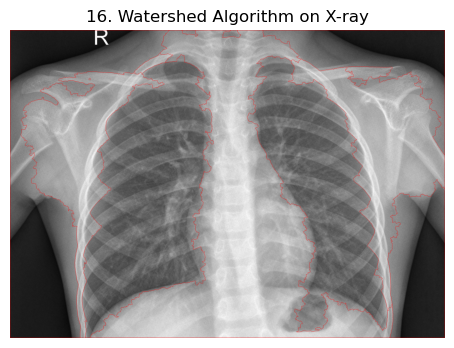

In [48]:
# 16: Watershed Algorithm (แยกวัตถุที่ซ้อนทับกัน) อัลกอริทึมชั้นสูงที่ใช้แยกวัตถุที่มีลักษณะกลมมนและซ้อนทับกัน (เช่น เม็ดเลือด) ออกจากกัน

# example paths
img_path = os.path.join(os.getcwd(), "images", "Xray.jpeg")

# load an image
img_xray_bgr  = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

img_xray_rgb = cv2.cvtColor(img_xray_bgr, cv2.COLOR_BGR2RGB)
img_xray_gray = cv2.cvtColor(img_xray_rgb, cv2.COLOR_BGR2GRAY)

show_image(img_xray_rgb, "Base Medical Image: Chest X-ray")

# ทำ Threshold ให้กลายเป็นภาพ Binary (ขาวคือส่วนทึบแสง ดำคือพื้นหลังและปอด)
ret, thresh_xray = cv2.threshold(img_xray_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# สร้าง Kernel สำหรับ Morphological operations
kernel_w = np.ones((3,3), np.uint8)

# ลด Noise ด้วย Opening
opening = cv2.morphologyEx(thresh_xray, cv2.MORPH_OPEN, kernel_w, iterations=2)

# พื้นที่ที่มั่นใจว่าเป็นพื้นหลัง (Background)
sure_bg = cv2.dilate(opening, kernel_w, iterations=3)

# พื้นที่ที่มั่นใจว่าเป็นวัตถุ (Foreground / กระดูก/เนื้อเยื่อแน่น)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.1 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# พื้นที่ที่ไม่แน่ใจ (รอยต่อ)
unknown = cv2.subtract(sure_bg, sure_fg)

# กำหนด Marker สำหรับ Watershed
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# บังคับชนิดข้อมูลและ Memory Layout เพื่อป้องกัน Error ของ cv2.watershed 
# (ต้องการภาพต้นฉบับเป็น uint8 3-channel และ markers เป็น int32)
markers = np.ascontiguousarray(markers, dtype=np.int32)
img_watershed = np.ascontiguousarray(img_xray_rgb, dtype=np.uint8)

# ทำ Watershed Algorithm
markers = cv2.watershed(img_watershed, markers)

# วาดเส้นแบ่งเขตแดนสีแดง (เช่น ขอบโครงร่างของเนื้อเยื่อหนา)
img_watershed[markers == -1] = [255, 0, 0] 

show_image(img_watershed, "16. Watershed Algorithm on X-ray")

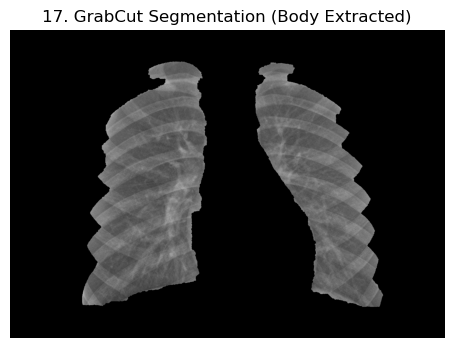

In [59]:
# 17: GrabCut Algorithm (ตัดเฉพาะช่วงทรวงอก) ให้คอมพิวเตอร์สกัดโครงร่างช่วงตัวมนุษย์ออกจากฉากหลังสีดำ โดยเราจะกำหนดกรอบสี่เหลี่ยมคลุมบริเวณตรงกลาง
# บังคับสร้างภาพ 3 แชนแนล (CV_8UC3) ใหม่จากภาพ Grayscale 
# เพื่อป้องกันปัญหาการอ่านไฟล์ภาพที่มีแชนแนลแปลกๆ (เช่น RGBA) ที่ทำให้ GrabCut Error
img_for_grabcut = cv2.cvtColor(img_xray_gray, cv2.COLOR_GRAY2BGR)
mask_grabcut = np.zeros(img_for_grabcut.shape[:2], np.uint8)

# โมเดลสำหรับ Background และ Foreground
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# กำหนดกรอบสี่เหลี่ยมคลุมเฉพาะลำตัว (เว้นขอบภาพ)
h, w = img_for_grabcut.shape[:2]
rect = (int(w*0.1), int(h*0.1), int(w*0.8), int(h*0.8))

# ทำ GrabCut เพื่อตัดฉากหลัง (Background) 
cv2.grabCut(img_for_grabcut, mask_grabcut, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

# สกัดเฉพาะ Foreground
mask2 = np.where((mask_grabcut == 2) | (mask_grabcut == 0), 0, 1).astype('uint8')
img_grabcut = img_xray_rgb * mask2[:, :, np.newaxis]

show_image(img_grabcut, "17. GrabCut Segmentation (Body Extracted)")


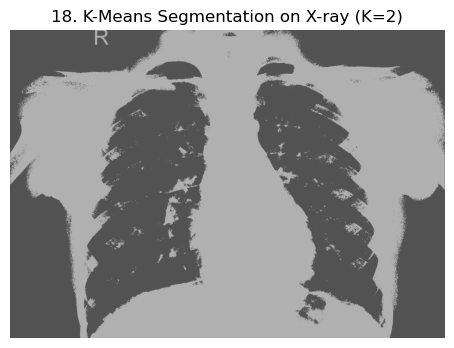

In [29]:
# 18: K-Means Clustering for Image Segmentation จัดกลุ่มระดับสีเทาเพื่อแยกประเภทอวัยวะ (เช่น พื้นหลัง, ปอดส่วนโปร่ง, กระดูกและเนื้อเยื่อหัวใจ) เราใช้ K=3 กลุ่ม
# แปลงโครงสร้างภาพให้เป็น Vector สำหรับประมวลผล K-Means
Z = img_xray_rgb.reshape((-1, 3))
Z = np.float32(Z)

# กำหนด K=3 (กลุ่มสี 3 ระดับ)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 2

# ทำ K-Means
ret, label, center = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# แปลงสีกลับเป็น uint8 และประกอบเป็นภาพเพื่อดูการแบ่งโซนความทึบแสง
center = np.uint8(center)
res_kmeans = center[label.flatten()]
res_kmeans = res_kmeans.reshape((img_xray_rgb.shape))

show_image(res_kmeans, f"18. K-Means Segmentation on X-ray (K={K})")

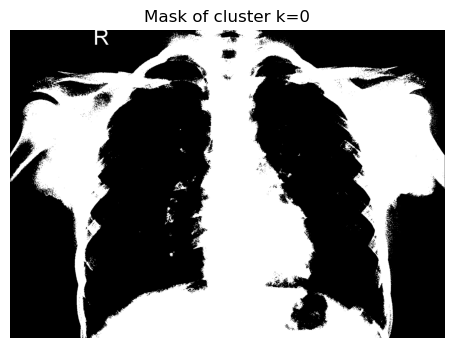

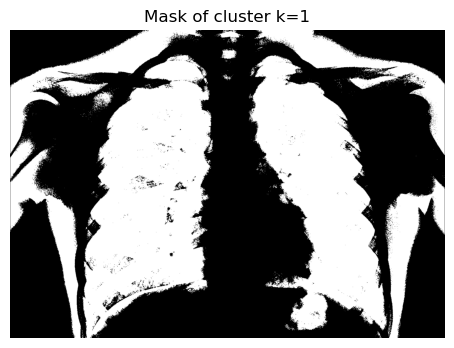

In [30]:
for i in range(K):
    mask = (labels_img == i).astype(np.uint8) * 255  # 0 หรือ 255
    show_image(cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB), f"Mask of cluster k={i}")

# สีขาว = พิกเซลที่อยู่ในคลัสเตอร์นั้น สีดำ = ไม่ใช่คลัสเตอร์นั้น    

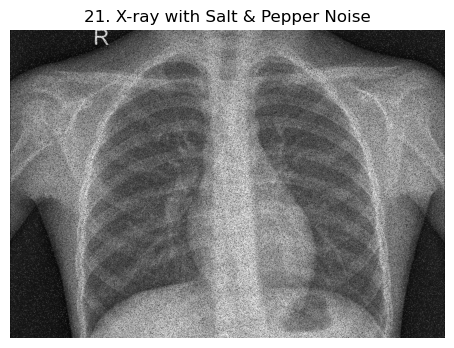

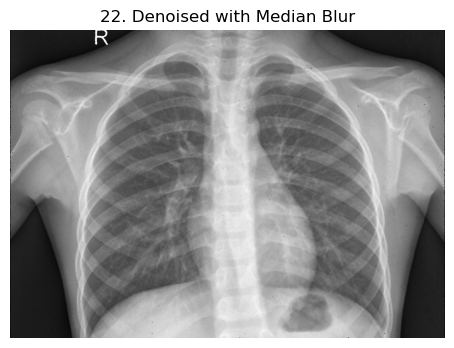

In [32]:
# สำเนาภาพต้นฉบับ
# example paths
img_path = os.path.join(os.getcwd(), "images", "Xray.jpeg")

# load an image
img_xray_bgr  = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

img_xray_rgb = cv2.cvtColor(img_xray_bgr, cv2.COLOR_BGR2RGB)
img_xray_gray = cv2.cvtColor(img_xray_rgb, cv2.COLOR_BGR2GRAY)
noisy_xray = img_xray_rgb.copy()

# สุ่มพิกเซลใส่ Noise
noise_matrix = np.random.randint(0, 100, noisy_xray.shape[:2])
noisy_xray[noise_matrix < 2] = [255, 255, 255]  # จุดสีขาว
noisy_xray[noise_matrix > 80] = [0, 0, 0]       # จุดสีดำ

show_image(noisy_xray, "21. X-ray with Salt & Pepper Noise")

# 22: Median Blur (กำจัดจุดรบกวนแบบจุด) Median Blur ทำงานได้ดีที่สุดในการลบ Noise ที่เกิดบนภาพเอกซเรย์โดยไม่ทำให้ภาพเบลอมาก
# ขนาด Kernel 5x5
median_blur = cv2.medianBlur(noisy_xray, 5)

show_image(median_blur, "22. Denoised with Median Blur")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-255.0..255.0].


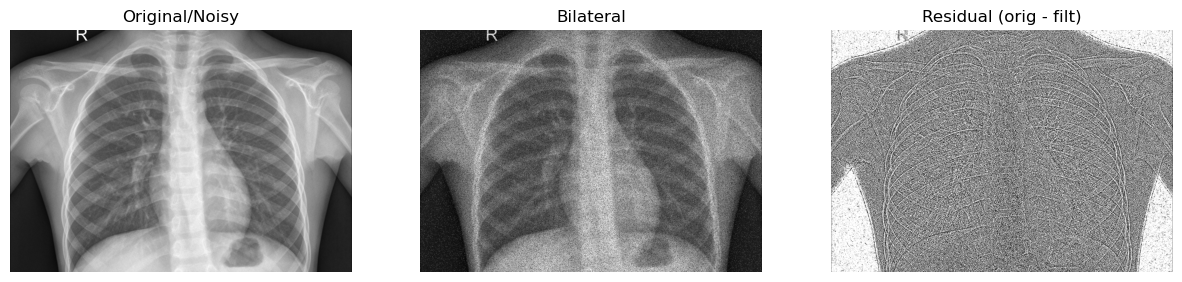

In [ ]:
# 23: Bilateral Filter (ลด Noise แบบรักษาเส้นขอบเนื้อเยื่อ) ทำให้พื้นที่ปอดดูเนียนขึ้น แต่ยังคงขอบของหัวใจและซี่โครงเอาไว้
# พารามิเตอร์: (ภาพ, ขอบเขตพิกเซล, Sigma สี, Sigma เชิงพื้นที่)
bilateral = cv2.bilateralFilter(noisy_xray, 9, 75, 75)


plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(img_xray_rgb, cmap='gray'); plt.title('Original/Noisy'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(bilateral, cmap='gray'); plt.title('Bilateral'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow((img_xray_rgb.astype('float32')-bilateral.astype('float32')), cmap='gray')
plt.title('Residual (orig - filt)'); plt.axis('off')
plt.show()

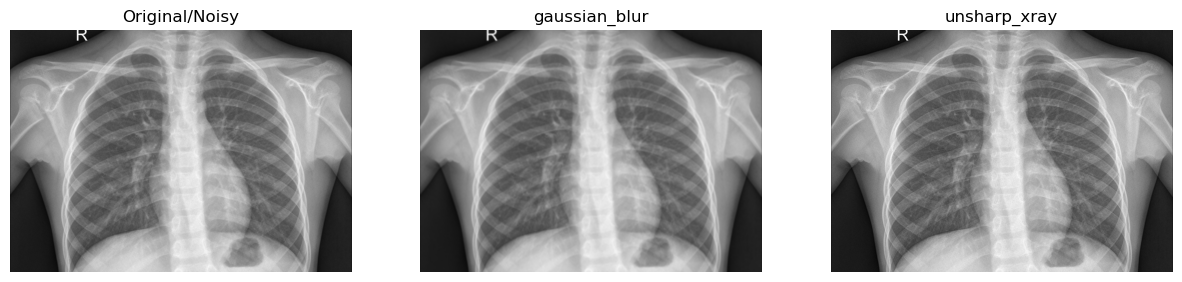

In [ ]:
# 26: Unsharp Masking (เน้นความคมชัด) เพิ่มความชัดของโครงสร้างใหญ่ๆ ภายในช่องอก
gaussian_blur = cv2.GaussianBlur(img_xray_rgb, (9, 9), 10.0)
unsharp_xray = cv2.addWeighted(img_xray_rgb, 1.5, gaussian_blur, -0.5, 0)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(img_xray_rgb, cmap='gray'); plt.title('Original/Noisy'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(gaussian_blur, cmap='gray'); plt.title('gaussian_blur'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(unsharp_xray, cmap='gray'); plt.title('unsharp_xray'); plt.axis('off')
plt.show()

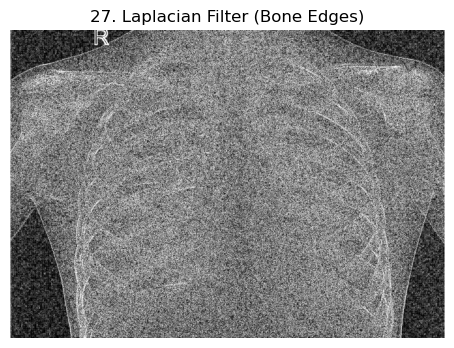

In [68]:
# 27: Laplacian Filter (จับขอบแบบรอบทิศ) แสดงโครงร่างขอบเขตทั้งหมดของกระดูกซี่โครงในภาพ

# ใช้ ksize=3 และ Normalize เพื่อดึงสเกลความสว่างของเส้นขอบขึ้นมาไม่ให้มืดสนิท
laplacian = cv2.Laplacian(img_xray_gray, cv2.CV_64F, ksize=5)
laplacian_abs = cv2.convertScaleAbs(laplacian)

# ปรับสมดุลแสงอัตโนมัติให้มองเห็นเส้นโครงสร้างที่คำนวณได้
laplacian_enhanced = cv2.normalize(laplacian_abs, None, 0, 255, cv2.NORM_MINMAX)

show_image(laplacian_enhanced, "27. Laplacian Filter (Bone Edges)", cmap_type='gray')

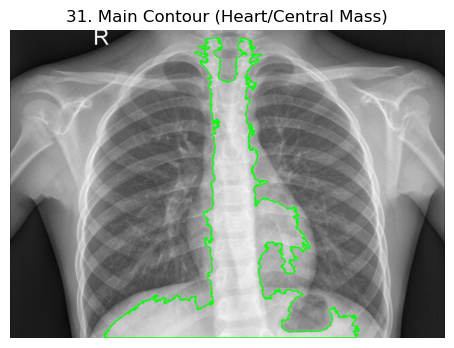

Area (พื้นที่ ROI): 363524.0 pixels^2
Perimeter (เส้นรอบวง): 14495.81 pixels


In [69]:
# แปลงเป็น Binary หาส่วนที่ทึบแสงตรงกลาง (หัวใจ)
_, thresh_heart = cv2.threshold(img_xray_gray, 180, 255, cv2.THRESH_BINARY)

# หา Contours
contours, _ = cv2.findContours(thresh_heart, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # เลือกบริเวณที่ใหญ่ที่สุด
    main_contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(main_contour)
    perimeter = cv2.arcLength(main_contour, True)

    # วาดเส้นรอบรูปที่พบเพื่อแสดงผล
    img_show_contour = img_xray_rgb.copy()
    cv2.drawContours(img_show_contour, [main_contour], -1, (0, 255, 0), 3)
    show_image(img_show_contour, "31. Main Contour (Heart/Central Mass)")

    print(f"Area (พื้นที่ ROI): {area} pixels^2")
    print(f"Perimeter (เส้นรอบวง): {perimeter:.2f} pixels")
else:
    print("ไม่พบโครงสร้างที่ชัดเจน ปรับค่า Threshold ใหม่")

Lung Region Mean Intensity: 49.94
Std Deviation: 27.15
Median: 34.0
Min: 0 | Max: 90


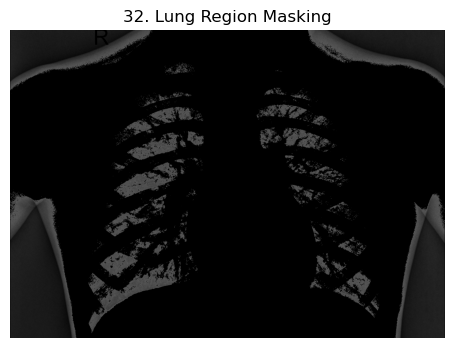

In [ ]:
# 32: สถิติความสว่างพิกเซลภายในปอด (First-Order Statistics) เราจะสร้าง Mask เพื่อวัดระดับความสว่าง (Hounsfield units จำลอง) ของปอด และแสดงผลพื้นที่ปอดที่ถูกดึงออกมา
# แยกเฉพาะส่วนปอด (สีดำ)
_, lung_mask = cv2.threshold(img_xray_gray, 90, 255, cv2.THRESH_BINARY_INV)

# ดึงค่าพิกเซลจากภาพต้นฉบับเฉพาะพื้นที่ปอด
lung_pixels = img_xray_gray[lung_mask == 255]

if len(lung_pixels) > 0:
    mean_intensity = np.mean(lung_pixels)
    std_intensity = np.std(lung_pixels)
    median_intensity = np.median(lung_pixels)
    max_intensity = np.max(lung_pixels)
    min_intensity = np.min(lung_pixels)

    print(f"Lung Region Mean Intensity: {mean_intensity:.2f}")
    print(f"Std Deviation: {std_intensity:.2f}")
    print(f"Median: {median_intensity}")
    print(f"Min: {min_intensity} | Max: {max_intensity}")
    
    # วาดพื้นที่ปอดที่ถูกแยกออกมาเพื่อแสดงผล
    img_lung_display = cv2.bitwise_and(img_xray_rgb, img_xray_rgb, mask=lung_mask)
    show_image(img_lung_display, "32. Lung Region Masking")

Aspect Ratio: 0.85
Solidity: 0.42
Circularity: 0.02


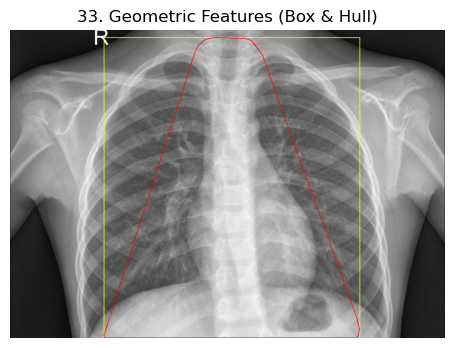

In [ ]:
# 33: การวัดคุณลักษณะเชิงเรขาคณิตขั้นสูง (Advanced Geometric Features) คำนวณความกลมและความแน่นของเนื้อเยื่อทึบส่วนกลาง (main_contour จากข้อ 31) พร้อมวาดกรอบ Bounding Box และ Convex Hull เพื่อให้เห็นภาพชัดเจน
if contours:
    x, y, w, h = cv2.boundingRect(main_contour)
    aspect_ratio = float(w) / h
    
    hull = cv2.convexHull(main_contour)
    hull_area = cv2.contourArea(hull)
    
    solidity = float(area) / hull_area if hull_area > 0 else 0
    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0

    print(f"Aspect Ratio: {aspect_ratio:.2f}")
    print(f"Solidity: {solidity:.2f}")
    print(f"Circularity: {circularity:.2f}")

    # วาด Bounding Box (สีเหลือง) และ Convex Hull (สีแดง) 
    img_geom = img_xray_rgb.copy()
    cv2.rectangle(img_geom, (x, y), (x+w, y+h), (255, 255, 0), 2)
    cv2.drawContours(img_geom, [hull], -1, (255, 0, 0), 2) # สีแดง (RGB)
    
    show_image(img_geom, "33. Geometric Features (Box & Hull)")

GLCM Contrast: 11.26
GLCM Homogeneity: 0.3391
GLCM Energy: 0.0637
GLCM Correlation: 0.9029


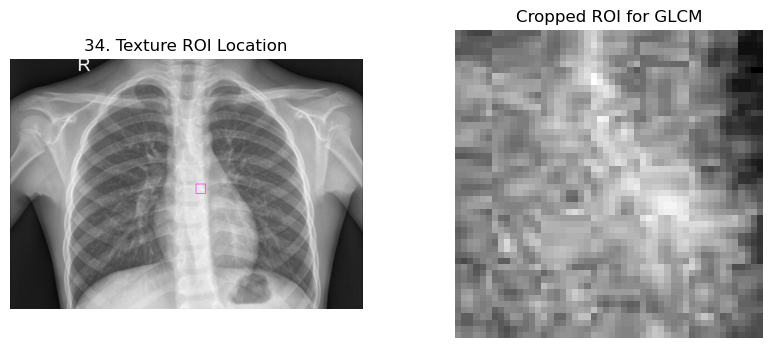

In [74]:
# 34: การวิเคราะห์พื้นผิวภาพ (Texture Analysis) ด้วย GLCM วัดความหยาบและลวดลายของเนื้อปอดตรงกลางภาพ พร้อมวาดกรอบแสดงตำแหน่ง ROI บนภาพดั้งเดิม

from skimage.feature import graycomatrix, graycoprops

# หาขนาดภาพเพื่อใช้เป็นจุดอ้างอิง
img_h, img_w = img_xray_gray.shape[:2]

# ตัดภาพบริเวณปอด/เนื้อเยื่อขวา (สมมติพิกัดให้เป็นบริเวณที่มี Texture)
start_y, end_y = img_h//2, img_h//2+50
start_x, end_x = img_w//2+50, img_w//2+100
roi_cropped = img_xray_gray[start_y:end_y, start_x:end_x]

if roi_cropped.shape[0] > 0 and roi_cropped.shape[1] > 0:
    # สร้าง GLCM
    glcm = graycomatrix(roi_cropped, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    print(f"GLCM Contrast: {contrast:.2f}")
    print(f"GLCM Homogeneity: {homogeneity:.4f}")
    print(f"GLCM Energy: {energy:.4f}")
    print(f"GLCM Correlation: {correlation:.4f}")
    
    # วาดกรอบแสดงตำแหน่ง ROI บนภาพต้นฉบับและแสดงภาพที่ถูกตัด
    img_roi_display = img_xray_rgb.copy()
    cv2.rectangle(img_roi_display, (start_x, start_y), (end_x, end_y), (255, 0, 255), 2)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_roi_display)
    ax1.set_title("34. Texture ROI Location")
    ax1.axis('off')
    ax2.imshow(roi_cropped, cmap='gray')
    ax2.set_title("Cropped ROI for GLCM")
    ax2.axis('off')
    plt.show()

==== 📊 สรุปชุดข้อมูล Radiomics Feature Vector ====


,Shape_Area,Shape_Solidity,Shape_Circularity,Lung_Mean,Lung_Std,GLCM_Contrast,GLCM_Homogeneity,GLCM_Energy
0,363524.0,0.419586,0.02174,49.943907,27.145915,11.26,0.339127,0.063679


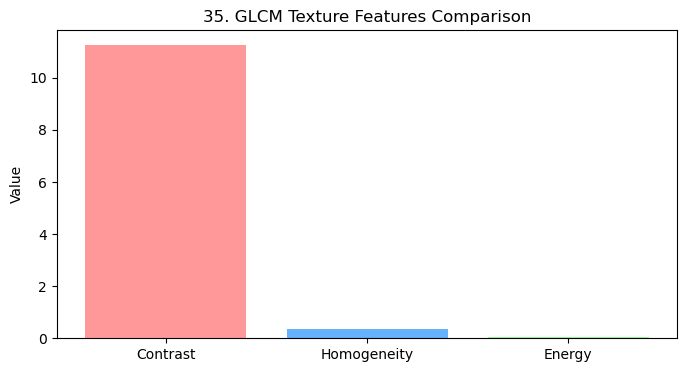

In [75]:
import pandas as pd

try:
    radiomics_features = {
        "Shape_Area": area,
        "Shape_Solidity": solidity,
        "Shape_Circularity": circularity,
        "Lung_Mean": mean_intensity,
        "Lung_Std": std_intensity,
        "GLCM_Contrast": contrast,
        "GLCM_Homogeneity": homogeneity,
        "GLCM_Energy": energy
    }

    df_features = pd.DataFrame([radiomics_features])
    print("==== 📊 สรุปชุดข้อมูล Radiomics Feature Vector ====")
    display(df_features) 
    
    # วาดกราฟแท่งแสดงค่า GLCM Features เปรียบเทียบกันให้ดูง่าย
    plt.figure(figsize=(8, 4))
    features_labels = ['Contrast', 'Homogeneity', 'Energy']
    features_values = [contrast, homogeneity, energy]
    plt.bar(features_labels, features_values, color=['#FF9999', '#66B2FF', '#99FF99'])
    plt.title('35. GLCM Texture Features Comparison')
    plt.ylabel('Value')
    plt.show()
    
except NameError:
    print("เกิดข้อผิดพลาด ให้แน่ใจว่าได้รันเซลล์ข้อ 31-34 ผ่านหมดแล้ว")